In [1]:
import os
from tools import *

import ants
import SimpleITK as sitk

print(f'AntsPy version = {ants.__version__}')
print(f'SimpleITK version = {sitk.__version__}')

AntsPy version = 0.6.3
SimpleITK version = 2.4.0


In [2]:
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
print(f'project folder = {BASE_DIR}')

project folder = /home/folkk2/img_group_project/test-MRI-preprocessing-technique


In [3]:
raw_img_path = os.path.join(BASE_DIR, 'assets', 'raw_examples', 'fsl-open-dev_sub-001_T1w.nii.gz')
print(f'raw_img_path = {raw_img_path}')
raw_example = 'fsl-open-dev_sub-001_T1w.nii.gz'

raw_img_path = /home/folkk2/img_group_project/test-MRI-preprocessing-technique/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz


## AntsPy

In [4]:
raw_img_ants = ants.image_read(raw_img_path)

In [5]:
print(raw_img_ants)

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (160, 192, 192)
	 Spacing    : (1.2, 1.25, 1.25)
	 Origin     : (98.1114, 89.5975, -129.5975)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]



## SimpleITK

In [6]:
raw_img_sitk = sitk.ReadImage(raw_img_path, sitk.sitkFloat32)

In [7]:
print(raw_img_sitk)

Image (0x44e73fd0)
  RTTI typeinfo:   itk::Image<float, 3u>
  Reference Count: 1
  Modified Time: 1838
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (none)
  Source output name: (none)
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 1812
  UpdateMTime: 1834
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [160, 192, 192]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [160, 192, 192]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [160, 192, 192]
  Spacing: [1.2, 1.25, 1.25]
  Origin: [98.1114, 89.5975, -129.597]
  Direction: 
-1 0 0
0 -1 0
0 0 1

  IndexToPointMatrix: 
-1.2 0 0
0 -1.25 0
0 0 1.25

  PointToIndexMatrix: 
-0.833333 0 0
0 -0.8 0
0 0 0.8

  Inverse Direction: 
-1 0 0
0 -1 0
0 0 1

  PixelContainer: 
    ImportImageContainer (0x4455f580)
      RTTI typeinfo:   itk::ImportImageContainer<unsigned long, float>
      Reference Count

## Resampling image

In [8]:
def resample_to_isotropic(img_path):
    # 1. Read the image
    img = sitk.ReadImage(img_path, sitk.sitkFloat32)
    
    # 2. Get original spacing and size
    original_spacing = img.GetSpacing()
    original_size = img.GetSize()
    
    print(f"Original Spacing: {original_spacing}")
    print(f"Original Size: {original_size}")
    
    # 3. Define the target spacing (1x1x1 mm)
    target_spacing = [1.2, 1.2, 1.2]
    
    # 4. Calculate the new size to maintain the same physical bounding box
    # New Size = Original Size * (Original Spacing / Target Spacing)
    new_size = [
        int(round(osz * ospc / tspc)) 
        for osz, ospc, tspc in zip(original_size, original_spacing, target_spacing)
    ]
    
    print(f"Target Spacing: {target_spacing}")
    print(f"New Size: {new_size}")
    
    # 5. Set up the resampler
    resampler = sitk.ResampleImageFilter()
    resampler.SetSize(new_size)
    resampler.SetOutputSpacing(target_spacing)
    
    # Crucial: Keep the original physical orientation and origin!
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(img.GetPixelIDValue())
    
    # Use BSpline or Linear interpolation for standard MRIs.
    # (Use sitk.sitkNearestNeighbor if resampling a segmentation mask!)
    resampler.SetInterpolator(sitk.sitkBSpline) 
    
    # 6. Execute resampling
    resampled_img = resampler.Execute(img)
    
    # Convert back to numpy array for visualization with ipywidgets
    # Note: SimpleITK returns arrays in (Z, Y, X) order, so we transpose to (X, Y, Z)
    resampled_array = sitk.GetArrayFromImage(resampled_img)
    
    return resampled_img, resampled_array

In [9]:
reimg, reimg_arr = resample_to_isotropic(raw_img_path)

Original Spacing: (1.2000000476837158, 1.25, 1.25)
Original Size: (160, 192, 192)
Target Spacing: [1.2, 1.2, 1.2]
New Size: [160, 200, 200]


In [10]:
explore_3D_array(reimg_arr)

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

In [11]:
resampling_img = sitk.DICOMOrient(reimg,'LPS')
print(resampling_img.GetDirection())
resampling_img_arr = sitk.GetArrayFromImage(resampling_img)
print(resampling_img_arr.shape)
explore_3D_array(resampling_img_arr)

(1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
(200, 200, 160)


interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

## Denoise

In [12]:
resampling_ants = ants.from_sitk(resampling_img)

transformed = ants.denoise_image(resampling_ants, shrink_factor=1)

explore_3D_array_comparison(
    arr_before=sitk.GetArrayFromImage(ants.to_sitk(resampling_ants)),
    arr_after=sitk.GetArrayFromImage(ants.to_sitk(transformed)),
    cmap='grey'
)

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

In [13]:
sitk_img_denoised = ants.to_sitk(transformed)
sitk_img_denoised_arr = sitk.GetArrayFromImage(ants.to_sitk(transformed))

## Save denoised image

In [14]:
out_folder =  os.path.join(BASE_DIR, 'assets', 'test-preprocessed')
out_folder = os.path.join(out_folder, raw_example.split('.')[0]) # create folder with name of the raw file
os.makedirs(out_folder, exist_ok=True) # create folder if not exists

out_filename = add_suffix_to_filename(raw_example, suffix='denoised')
out_path = os.path.join(out_folder, out_filename)

print(raw_img_path[len(BASE_DIR):])
print(out_path[len(BASE_DIR):])

/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz
/assets/test-preprocessed/fsl-open-dev_sub-001_T1w/fsl-open-dev_sub-001_T1w_denoised.nii.gz


In [15]:
sitk.WriteImage(sitk_img_denoised, out_path)

## Bias Field Correction

In [14]:
explore_3D_array(sitk_img_denoised_arr)

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Create Head Mask

In [15]:
transformed_img = sitk.RescaleIntensity(sitk_img_denoised, 0, 255)

#transformed = sitk.TriangleThreshold(transformed, 0, 1)
transformed_img = sitk.LiThreshold(transformed_img,0,1)

head_mask = transformed_img

explore_3D_array_comparison(
    arr_before=sitk.GetArrayFromImage(sitk_img_denoised),
    arr_after=sitk.GetArrayFromImage(head_mask)
)

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Bias Correction

In [16]:
shrinkFactor = 1
inputImage = sitk_img_denoised

inputImage = sitk.Shrink( sitk_img_denoised, [ shrinkFactor ] * inputImage.GetDimension() )
maskImage = sitk.Shrink( head_mask, [ shrinkFactor ] * inputImage.GetDimension() )

bias_corrector = sitk.N4BiasFieldCorrectionImageFilter()

corrected = bias_corrector.Execute(inputImage, maskImage)

### Get image corrected

In [17]:
log_bias_field = bias_corrector.GetLogBiasFieldAsImage(sitk_img_denoised)
corrected_image_full_resolution = sitk_img_denoised / sitk.Exp( log_bias_field )

explore_3D_array_comparison(
    sitk.GetArrayFromImage(sitk_img_denoised),
    sitk.GetArrayFromImage(corrected_image_full_resolution), 
    cmap='nipy_spectral')

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Inspect the bias field

In [18]:
# bias field
temp = sitk.Exp(log_bias_field)
temp = sitk.Mask(temp, head_mask)
explore_3D_array(sitk.GetArrayFromImage(temp), cmap='grey')

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Save Corrected image

In [23]:
out_folder =  os.path.join(BASE_DIR, 'assets', 'test-preprocessed')
out_folder = os.path.join(out_folder, raw_example.split('.')[0]) # create folder with name of the raw file
os.makedirs(out_folder, exist_ok=True) # create folder if not exists

out_filename = add_suffix_to_filename(raw_example, suffix='biasFieldCorrected')
out_path = os.path.join(out_folder, out_filename)

print(raw_img_path[len(BASE_DIR):])
print(out_path[len(BASE_DIR):])

/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz
/assets/test-preprocessed/fsl-open-dev_sub-001_T1w/fsl-open-dev_sub-001_T1w_biasFieldCorrected.nii.gz


In [24]:
sitk.WriteImage(corrected_image_full_resolution, out_path)

## Brain extraction

In [19]:
from antspynet.utilities import brain_extraction

I0000 00:00:1773303841.598990    1420 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
ants_img_corrected = ants.from_sitk(corrected_image_full_resolution)
ants_img_corrected = ants.reorient_image2(ants_img_corrected, orientation='IAL')

In [21]:
explore_3D_array(ants_img_corrected.numpy())

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

In [92]:
prob_brain_mask = brain_extraction(ants_img_corrected,modality="t1",verbose=True)

Brain extraction:  retrieving model weights.
Brain extraction:  retrieving template.
Brain extraction:  normalizing image to the template.
Brain extraction:  prediction and decoding.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Brain extraction:  renormalize probability mask to native space.


### Inspect probabilities array

In [93]:
print(prob_brain_mask)
explore_3D_array(prob_brain_mask.numpy())

ANTsImage (IAL)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (200, 200, 160)
	 Spacing    : (1.2, 1.2, 1.2)
	 Origin     : (98.1114, -149.2025, -129.5975)
	 Direction  : [ 0.  0. -1.  0.  1.  0.  1.  0.  0.]



interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Generate final mask

In [24]:
brain_mask = ants.get_mask(prob_brain_mask, low_thresh=0.5)

In [25]:
explore_3D_array_with_mask_contour(ants_img_corrected.numpy(), brain_mask.numpy())

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Save Mask

In [34]:
out_folder =  os.path.join(BASE_DIR, 'assets', 'test-preprocessed')
out_folder = os.path.join(out_folder, raw_example.split('.')[0]) # create folder with name of the raw file
os.makedirs(out_folder, exist_ok=True) # create folder if not exists

out_filename = add_suffix_to_filename(raw_example, suffix='brainMaskByDL')
out_path = os.path.join(out_folder, out_filename)

print(raw_img_path[len(BASE_DIR):])
print(out_path[len(BASE_DIR):])

/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz
/assets/test-preprocessed/fsl-open-dev_sub-001_T1w/fsl-open-dev_sub-001_T1w_brainMaskByDL.nii.gz


In [35]:
brain_mask.to_file(out_path)

### Generate brain masked

In [26]:
masked = ants.mask_image(ants_img_corrected, brain_mask)

explore_3D_array(masked.numpy())

interactive(children=(IntSlider(value=99, description='SLICE', max=199), Output()), _dom_classes=('widget-inte…

### Save Masked Brain

In [37]:
out_filename = add_suffix_to_filename(raw_example, suffix='brainMaskedByDL')
out_path = os.path.join(out_folder, out_filename)

print(raw_img_path[len(BASE_DIR):])
print(out_path[len(BASE_DIR):])

/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz
/assets/test-preprocessed/fsl-open-dev_sub-001_T1w/fsl-open-dev_sub-001_T1w_brainMaskedByDL.nii.gz


In [38]:
masked.to_file(out_path)

## Spatial Normalization(registration)

### Template image

In [27]:
template_img_path = os.path.join(BASE_DIR, 'assets', 'templates', 'tpl-MNI152NLin2009cAsym_space-MNI_res-01_T1w_brain.nii')
template_img_ants = ants.image_read(template_img_path, reorient='IAL')

explore_3D_array(arr = template_img_ants.numpy())

interactive(children=(IntSlider(value=96, description='SLICE', max=192), Output()), _dom_classes=('widget-inte…

In [28]:
print('\t\tMasked IMG')
print(masked)

print('\t\tTEMPLATE IMG')
print(template_img_ants)

		Masked IMG
ANTsImage (IAL)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (200, 200, 160)
	 Spacing    : (1.2, 1.2, 1.2)
	 Origin     : (98.1114, -149.2025, -129.5975)
	 Direction  : [ 0.  0. -1.  0.  1.  0.  1.  0.  0.]

		TEMPLATE IMG
ANTsImage (IAL)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (193, 229, 193)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (96.0, -96.0, -78.0)
	 Direction  : [ 0.  0. -1.  0.  1.  0.  1.  0.  0.]



### Registration

In [31]:
transformation_masked = ants.registration(
    fixed=template_img_ants,
    moving=masked, 
    type_of_transform='SyN',
    verbose=True
)

antsRegistration --dimensionality 3 -r [0x77ae90534488,0x77ae90534b88,1] --metric mattes[0x77ae90534488,0x77ae90534b88,1,32,regular,0.2] --transform Affine[0.25] --convergence 2100x1200x1200x0 --smoothing-sigmas 3x2x1x0 --shrink-factors 4x2x2x1 -x [NA,NA] --metric mattes[0x77ae90534488,0x77ae90534b88,1,32] --transform SyN[0.200000,3.000000,0.000000] --convergence [40x20x0,1e-7,8] --smoothing-sigmas 2x1x0 --shrink-factors 4x2x1 -u 0 -z 1 --output [/tmp/tmp8xih4d78,0x77ae905363e8,0x77ae90535108] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1
All_Command_lines_OK
Using single precision for computations.
The composite transform comprises the following transforms (in order): 
  1. Center of mass alignment using fixed image: 0x77ae90534488 and moving image: 0x77ae90534b88 (type = Euler3DTransform)
  Reading mask(s).
    Registration stage 0
      No fixed mask
      No moving mask
    Registration stage 1
      No fixed mask
      No moving mask
  number of levels = 4
  number of le

In [32]:
print(transformation_masked)

{'warpedmovout': ANTsImage (IAL)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (193, 229, 193)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (96.0, -96.0, -78.0)
	 Direction  : [ 0.  0. -1.  0.  1.  0.  1.  0.  0.]
, 'warpedfixout': ANTsImage (IAL)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (200, 200, 160)
	 Spacing    : (1.2, 1.2, 1.2)
	 Origin     : (98.1114, -149.2025, -129.5975)
	 Direction  : [ 0.  0. -1.  0.  1.  0.  1.  0.  0.]
, 'fwdtransforms': ['/tmp/tmp8xih4d781Warp.nii.gz', '/tmp/tmp8xih4d780GenericAffine.mat'], 'invtransforms': ['/tmp/tmp8xih4d780GenericAffine.mat', '/tmp/tmp8xih4d781InverseWarp.nii.gz']}


In [33]:
registered_img_ants = transformation_masked['warpedmovout']

explore_3D_array(arr=registered_img_ants.numpy())

interactive(children=(IntSlider(value=96, description='SLICE', max=192), Output()), _dom_classes=('widget-inte…

### Save registration image

In [104]:
out_folder =  os.path.join(BASE_DIR, 'assets', 'test-preprocessed')
out_folder = os.path.join(out_folder, raw_example.split('.')[0]) # create folder with name of the raw file
os.makedirs(out_folder, exist_ok=True) # create folder if not exists

out_filename = add_suffix_to_filename(raw_example, suffix='registered')
out_path = os.path.join(out_folder, out_filename)

print(raw_img_path[len(BASE_DIR):])
print(out_path[len(BASE_DIR):])

/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz
/assets/test-preprocessed/fsl-open-dev_sub-001_T1w/fsl-open-dev_sub-001_T1w_registered.nii.gz


In [105]:
registered_img_ants.to_file(out_path)

## Intensity Normalization

In [41]:
sitk_registered_img = ants.to_sitk(registered_img_ants)
sitk_registered_img = sitk.DICOMOrient(sitk_registered_img,'LPS')
explore_3D_array(sitk.GetArrayFromImage(sitk_registered_img))

interactive(children=(IntSlider(value=96, description='SLICE', max=192), Output()), _dom_classes=('widget-inte…

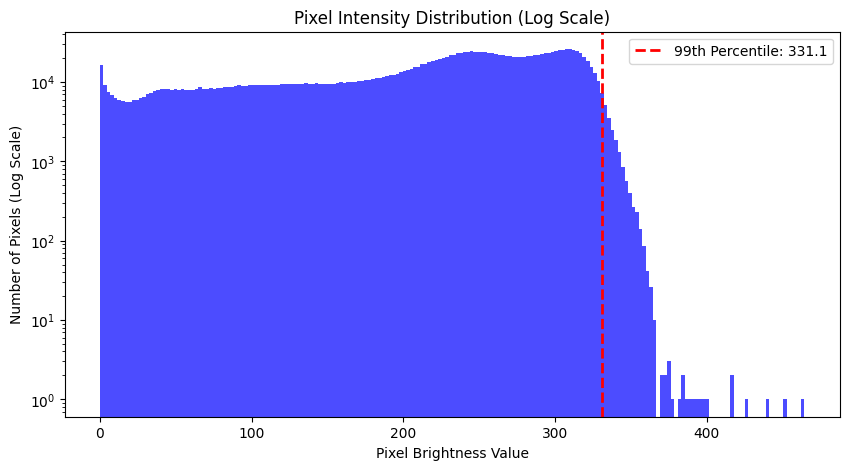

In [42]:
img_array = sitk.GetArrayFromImage(sitk_registered_img)
# 2. Get ONLY the brain pixels (ignore the black background)
brain_pixels = img_array[img_array > 0]

# 3. Plot the Histogram
plt.figure(figsize=(10, 5))
# bins=200 gives a high-resolution graph
plt.hist(brain_pixels, bins=200, color='blue', alpha=0.7, log=True) 

plt.title("Pixel Intensity Distribution (Log Scale)")
plt.xlabel("Pixel Brightness Value")
plt.ylabel("Number of Pixels (Log Scale)")

# Calculate the 99th percentile to draw a line where the clipping will happen
p99 = np.percentile(brain_pixels, 99)
plt.axvline(p99, color='red', linestyle='dashed', linewidth=2, label=f'99th Percentile: {p99:.1f}')

plt.legend()
plt.show()

In [44]:
# Sort the brain pixels from lowest to highest
sorted_pixels = np.sort(brain_pixels)

# Print the last 20 values (the absolute brightest pixels)
print("The 20 brightest pixels in this scan are:")
print(sorted_pixels[-20:])

# Compare it to the 99th percentile
print(f"\nFor context, the 99th percentile cutoff is: {np.percentile(brain_pixels, 99):.1f}")

The 20 brightest pixels in this scan are:
[374.0981  374.9031  375.60526 378.23154 382.04755 383.84872 384.51547
 386.7465  388.156   391.25787 393.51172 396.43765 397.99023 399.7198
 416.0541  417.2428  427.22293 439.06342 450.99545 464.49988]

For context, the 99th percentile cutoff is: 331.1


In [101]:
import SimpleITK as sitk

def normalize_intensity_zscore(sitk_image):
    """
    Applies 1st-99th percentile clipping and masked Z-score normalization.
    """
    # 1. Convert SimpleITK image to a NumPy array (Format: Float32)
    img_array = sitk.GetArrayFromImage(sitk_image).astype(np.float32)
    
    # 2. Create a mask of the brain (ignoring the exact 0 background)
    brain_mask = img_array > 0
    
    # Extract just the brain pixels as a 1D list
    brain_pixels = img_array[brain_mask]
    
    # 3. Percentile Clipping (1st and 99th)
    p1, p99 = np.percentile(brain_pixels, [1, 99])
    
    # Clip the whole array, but we will fix the background in a moment
    img_array = np.clip(img_array, a_min=p1, a_max=p99)
    
    # Get the updated brain pixels after clipping
    brain_pixels_clipped = img_array[brain_mask]
    
    # 4. Calculate the true Mean and Standard Deviation of the brain
    mean_val = np.mean(brain_pixels_clipped)
    std_val = np.std(brain_pixels_clipped)
    
    # 5. Apply the Z-score formula ONLY to the brain area
    normalized_array = np.copy(img_array)
    normalized_array[brain_mask] = (img_array[brain_mask] - mean_val) / std_val
    
    # 6. Force the background to be exactly 0 (or a specific value like -5 if your CNN prefers)
    normalized_array[~brain_mask] = 0.0
    
    # 7. Convert back to SimpleITK, preserving the MNI spatial coordinates
    normalized_image = sitk.GetImageFromArray(normalized_array)
    normalized_image.CopyInformation(sitk_image)
    
    return normalized_image

In [102]:
final_ready_brain = normalize_intensity_zscore(sitk_registered_img)

In [113]:
explore_3D_array_comparison(sitk.GetArrayFromImage(sitk_registered_img),
                            sitk.GetArrayFromImage(final_ready_brain))

interactive(children=(IntSlider(value=96, description='SLICE', max=192), Output()), _dom_classes=('widget-inte…

In [107]:
out_folder =  os.path.join(BASE_DIR, 'assets', 'test-preprocessed')
out_folder = os.path.join(out_folder, raw_example.split('.')[0]) # create folder with name of the raw file
os.makedirs(out_folder, exist_ok=True) # create folder if not exists

out_filename = add_suffix_to_filename(raw_example, suffix='final')
out_path = os.path.join(out_folder, out_filename)

print(raw_img_path[len(BASE_DIR):])
print(out_path[len(BASE_DIR):])

/assets/raw_examples/fsl-open-dev_sub-001_T1w.nii.gz
/assets/test-preprocessed/fsl-open-dev_sub-001_T1w/fsl-open-dev_sub-001_T1w_final.nii.gz


In [109]:
sitk.WriteImage(final_ready_brain, out_path)